In [1]:
import pandas as pd
import lecilab_behavior_analysis.utils as utils
from pathlib import Path
import subprocess
from datetime import datetime
import random
import deeplabcut
import os
from IPython.display import Video, display

Loading DLC 3.0.0rc10...


/home/kudongdong/anaconda3/envs/DLC/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
acv_project_name = "visual_and_COT_data"
nuo_project_name = "COT_cannula_data"
escape_project_name = "auditory_escape_data"
project_path = f"/archive/training_village/"
working_dir = "/home/kudongdong/DLC_projects"

# create new project

In [6]:
acv_animals = [f"ACV{str(i).zfill(3)}" for i in range(1, 11)]
nuo_animals = [f"NUO{str(i).zfill(3)}" for i in range(1, 13)]
escape_animals = [f"NUO{str(i).zfill(3)}" for i in [20, 21, 22, 24, 25]]
escape_animals_2nd = [f"ACV{str(i).zfill(3)}" for i in range(11, 23)]
modelVideo_name = []
for animal in escape_animals_2nd:
    escape_videos_path = Path(f"{project_path}{escape_project_name}/videos/{animal}/")

    # Get all files from the server for this animal
    escape_files = os.listdir(escape_videos_path)
    escape_video_files = [f for f in escape_files if f.endswith('.mp4')]
    
    # # Filter for MP4 files and separate by experiment type
    # habituation_videos = [f for f in files if f.endswith('.mp4') and 'Habituation' in f]
    # twoafc_videos = [f for f in files if f.endswith('.mp4') and 'TwoAFC' in f]
    # mirror_videos = [f for f in files if f.endswith('.mp4') and ('_20250723_' in f or '_20250724_' in f)]

    # modelVideo_name.extend([f"{videos_path}/{i}" for i in random.sample(habituation_videos, 1)])
    # modelVideo_name.extend([f"{videos_path}/{i}" for i in random.sample(twoafc_videos, 4)])
    # modelVideo_name.extend([f"{videos_path}/{i}" for i in random.sample(mirror_videos, 2)])

    # Randomly select 3 videos from all available videos
    modelVideo_name.extend([f"{escape_videos_path}/{i}" for i in random.sample(escape_video_files, 3)])

print(modelVideo_name)

['/archive/training_village/auditory_escape_data/videos/ACV011/ACV011_EscapeBehavior_20260128_075807.mp4', '/archive/training_village/auditory_escape_data/videos/ACV011/ACV011_EscapeBehavior_20260126_083417.mp4', '/archive/training_village/auditory_escape_data/videos/ACV011/ACV011_EscapeBehavior_20260127_081432.mp4', '/archive/training_village/auditory_escape_data/videos/ACV012/ACV012_EscapeBehavior_20260126_094647.mp4', '/archive/training_village/auditory_escape_data/videos/ACV012/ACV012_EscapeBehavior_20260128_090647.mp4', '/archive/training_village/auditory_escape_data/videos/ACV012/ACV012_EscapeBehavior_20260127_092240.mp4', '/archive/training_village/auditory_escape_data/videos/ACV013/ACV013_EscapeBehavior_20260128_101903.mp4', '/archive/training_village/auditory_escape_data/videos/ACV013/ACV013_EscapeBehavior_20260127_103246.mp4', '/archive/training_village/auditory_escape_data/videos/ACV013/ACV013_EscapeBehavior_20260126_110042.mp4', '/archive/training_village/auditory_escape_da

In [5]:
deeplabcut.create_new_project(
    project="escape_auditory",
    experimenter="LeciLab",
    videos=modelVideo_name,
    working_directory=working_dir,
    copy_videos=False,
    multianimal=False,
    videotype='.mp4'
)

Created "/home/kudongdong/DLC_projects/escape_auditory-LeciLab-2025-10-20/videos"
Created "/home/kudongdong/DLC_projects/escape_auditory-LeciLab-2025-10-20/labeled-data"
Created "/home/kudongdong/DLC_projects/escape_auditory-LeciLab-2025-10-20/training-datasets"
Created "/home/kudongdong/DLC_projects/escape_auditory-LeciLab-2025-10-20/dlc-models"
Attempting to create a symbolic link of the video ...
Created the symlink of /archive/training_village/auditory_escape_data/videos/NUO031/NUO031_EscapeBehavior_20251017_172815.mp4 to /home/kudongdong/DLC_projects/escape_auditory-LeciLab-2025-10-20/videos/NUO031_EscapeBehavior_20251017_172815.mp4
Created the symlink of /archive/training_village/auditory_escape_data/videos/NUO032/NUO032_EscapeBehavior_20251017_183606.mp4 to /home/kudongdong/DLC_projects/escape_auditory-LeciLab-2025-10-20/videos/NUO032_EscapeBehavior_20251017_183606.mp4
/home/kudongdong/DLC_projects/escape_auditory-LeciLab-2025-10-20/videos/NUO031_EscapeBehavior_20251017_172815.m

'/home/kudongdong/DLC_projects/escape_auditory-LeciLab-2025-10-20/config.yaml'

# configure the config file

# import existed project

In [4]:
DLC_model_projects = "/home/kudongdong/DLC_projects"
DLC_projects_name = os.listdir(DLC_model_projects)
print(DLC_projects_name)

['TrainingVillage_2AFC-LeciLab-2025-10-06', 'escape_auditory-LeciLab-2025-10-20', 'TrainingVillage_2AFC_multianimal-LeciLab-2025-10-12', 'TrainingVillage001-LeciLab-2025-09-04', 'TrainingVillage_2AFC_superanimal-LeciLab-2025-10-16', 'TrainingVillage001_v2-LeciLab-2025-09-25', 'TrainingVillage_2AFC-LeciLab-2025-10-09']


In [5]:
DLC_project_name = DLC_projects_name[1]
config_path = f"{DLC_model_projects}/{DLC_project_name}/config.yaml"
print(DLC_project_name)

escape_auditory-LeciLab-2025-10-20


# Extract frames

In [10]:
deeplabcut.extract_frames(
    config_path,
    mode="automatic",
    algo="kmeans",
    crop=False,
    userfeedback=False
)

Config file read successfully.
Extracting frames based on kmeans ...
Kmeans-quantization based extracting of frames from 0.0  seconds to 3530.56  seconds.
Extracting and downsampling... 105952  frames from the video.


0it [00:00, ?it/s]

105952it [03:17, 535.59it/s]


Kmeans clustering ... (this might take a while)
Extracting frames based on kmeans ...
Kmeans-quantization based extracting of frames from 0.0  seconds to 7064.25  seconds.
Extracting and downsampling... 211998  frames from the video.


211998it [06:40, 529.56it/s]


Kmeans clustering ... (this might take a while)
Frames were successfully extracted, for the videos listed in the config.yaml file.

You can now label the frames using the function 'label_frames' (Note, you should label frames extracted from diverse videos (and many videos; we do not recommend training on single videos!)).


[False, False]

# download the model folder to local and label the training set

# train the model

In [28]:
deeplabcut.create_training_dataset(config_path)

INFO:root:Default augmenter albumentations not available for engine Engine.PYTORCH: using albumentations instead


[(0.95,
  1,
  (array([2093, 1466, 1602, ...,  226, 1937, 1944]),
   array([ 524,  903, 1817, 1318,  787, 1157,  820,  890,  891,  360, 1258,
          1673,  163, 1025,  428, 1862,  139,  958,  684,  220, 1896, 1633,
            47,    7,  842, 1116, 1928, 1575,  639, 1689,  835,  488,  756,
           857, 1134, 1202,  628, 1117,   67,  449, 1667,  335, 1921, 1875,
          1845,  564, 1756, 1757, 1086, 2138,  979,  267,  307, 2142, 1164,
           727, 2145,  621,  299, 1312, 1132,  162,  562, 1775,  870, 1294,
          1224, 2094, 1949,  950,  701,  856, 1644, 1042, 1387, 1026,  399,
          1813, 1664,  209,  663, 1144,   36, 1388, 1653, 1290, 1141,  382,
          2115,  362, 1642,  401,  611, 1558,    2,   17, 1462,   14, 2020,
           140,  365,  859, 1298, 2092, 1496, 1188,  132, 1924])))]

In [5]:
# put this in .py file
deeplabcut.train_network(
    config_path,
    shuffle=1,
    trainingsetindex=0,
    device="cuda:1",
    max_snapshots_to_keep=10,
    displayiters=100,
    save_epochs=25,
    epochs=250,
    # snapshot_path = "/home/kudongdong/DLC_projects/TrainingVillage001_v2-LeciLab-2025-09-25/dlc-models-pytorch/iteration-0/TrainingVillage001_v2Sep25-trainset95shuffle1/train/snapshot-300.pt"
)

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
metadata:
  project_path: /home/kudongdong/DLC_projects/TrainingVillage_2AFC-LeciLab-2025-10-09
  pose_config_path: /home/kudongdong/DLC_projects/TrainingVillage_2AFC-LeciLab-2025-10-09/dlc-models-pytorch/iteration-3/TrainingVillage_2AFCOct9-trainset95shuffle1/train/pytorch_config.yaml
  bodyparts: ['Nose', 'Left_ear', 'Right_ear', 'Left_fhip', 'Right_fhip', 'Left_bhip', 'Right_bhip', 'Spine1', 'Center', 'Spine2', 'Tail_base', 'Tail1', 'Tail2', 'Tail_tip']
  unique_bodyparts: []
  individuals: ['animal']
  with_identity: None
method: bu
model:
  backbone:
    type: ResNet
    model_name: resnet50_g

In [ ]:
# train_py = os.path.join(DLC_model_projects, DLC_project_name, "train.py")
# log_file = os.path.join(DLC_model_projects, DLC_project_name, "train.log")

# with open(log_file, "w") as f:
#     subprocess.Popen(
#         ["python", "-u", train_py],
#         stdout=f,
#         stderr=subprocess.STDOUT
#     )


# evaluate network

In [5]:
deeplabcut.evaluate_network(config_path, Shuffles=[1], plotting=True)

Evaluation scorer: DLC_Resnet50_TrainingVillage_2AFCOct9shuffle1_snapshot_best-170


100%|██████████| 108/108 [00:01<00:00, 83.88it/s]


Evaluation results file: DLC_Resnet50_TrainingVillage_2AFCOct9shuffle1_snapshot_best-170-results.csv
Evaluation results for DLC_Resnet50_TrainingVillage_2AFCOct9shuffle1_snapshot_best-170-results.csv (pcutoff: 0.6):
train rmse             1.67
train rmse_pcutoff     1.41
train mAP             97.53
train mAR             98.09
test rmse              4.91
test rmse_pcutoff      4.56
test mAP              93.85
test mAR              95.00
Name: (0.95, 1, 170, -1, 0.6), dtype: float64


In [6]:
import matplotlib.pyplot as plt
import os
import numpy as np

In [7]:


def find_subdir(parent_dir, target_name):
    for root, dirs, files in os.walk(parent_dir):
        if target_name in dirs:
            return os.path.join(root, target_name)
    return None

In [8]:
learnStats_df_v1 = pd.read_csv(find_subdir(Path(f"{DLC_model_projects}/{DLC_project_name}/dlc-models-pytorch/iteration-0"), "train")+"/learning_stats.csv")
learnStats_df_v2 = pd.read_csv(find_subdir(Path(f"{DLC_model_projects}/{DLC_project_name}/dlc-models-pytorch/iteration-1"), "train")+"/learning_stats.csv")
learnStats_df_v3 = pd.read_csv(find_subdir(Path(f"{DLC_model_projects}/{DLC_project_name}/dlc-models-pytorch/iteration-2"), "train")+"/learning_stats.csv")
learnStats_df_v4 = pd.read_csv(find_subdir(Path(f"{DLC_model_projects}/{DLC_project_name}/dlc-models-pytorch/iteration-3"), "train")+"/learning_stats.csv")

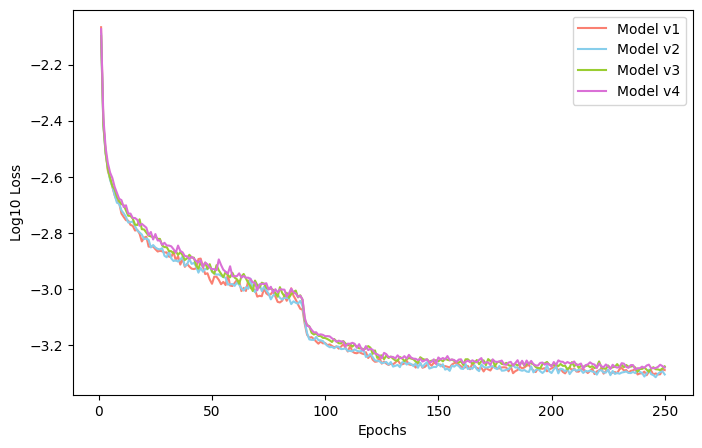

In [9]:
fig = plt.figure(figsize=(8, 5))   
learnStats_df_v1['log10_loss'] = np.log10(learnStats_df_v1["losses/train.total_loss"])
plt.plot(learnStats_df_v1.step, learnStats_df_v1["log10_loss"], c = "salmon", label="Model v1")
learnStats_df_v2['log10_loss'] = np.log10(learnStats_df_v2["losses/train.total_loss"])
plt.plot(learnStats_df_v2.step, learnStats_df_v2["log10_loss"], c = "skyblue", label="Model v2")
learnStats_df_v3['log10_loss'] = np.log10(learnStats_df_v3["losses/train.total_loss"])
plt.plot(learnStats_df_v3.step, learnStats_df_v3["log10_loss"], c = "yellowgreen", label="Model v3")
learnStats_df_v4['log10_loss'] = np.log10(learnStats_df_v4["losses/train.total_loss"])
plt.plot(learnStats_df_v4.step, learnStats_df_v4["log10_loss"], c = "orchid", label="Model v4")
plt.ylabel("Log10 Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show()

/home/kudongdong/tmp/ipykernel_3226851/35091925.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mapdf_v1.dropna(inplace=True)
/home/kudongdong/tmp/ipykernel_3226851/35091925.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mapdf_v2.dropna(inplace=True)
/home/kudongdong/tmp/ipykernel_3226851/35091925.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mapdf_v3.dropna(inplace=True)
/home/kudongdong/tmp/ipykernel_3226851/35091925.p

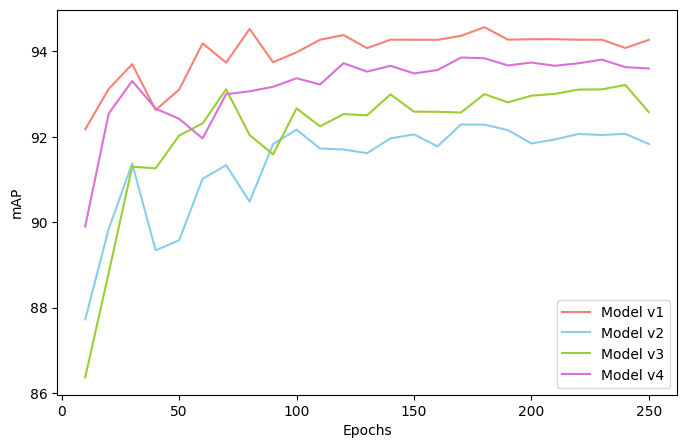

In [10]:
fig = plt.figure(figsize=(8, 5))
mapdf_v1 = learnStats_df_v1[['step', "metrics/test.mAP"]]
mapdf_v1.dropna(inplace=True)
plt.plot(mapdf_v1.step, mapdf_v1['metrics/test.mAP'], c = 'salmon', label="Model v1")
mapdf_v2 = learnStats_df_v2[['step', "metrics/test.mAP"]]
mapdf_v2.dropna(inplace=True)
plt.plot(mapdf_v2.step, mapdf_v2['metrics/test.mAP'], c = 'skyblue', label="Model v2")
mapdf_v3 = learnStats_df_v3[['step', "metrics/test.mAP"]]
mapdf_v3.dropna(inplace=True)
plt.plot(mapdf_v3.step, mapdf_v3['metrics/test.mAP'], c = 'yellowgreen', label="Model v3")
mapdf_v4 = learnStats_df_v4[['step', "metrics/test.mAP"]]
mapdf_v4.dropna(inplace=True)
plt.plot(mapdf_v4.step, mapdf_v4['metrics/test.mAP'], c = 'orchid', label="Model v4")
plt.xlabel('Epochs')
plt.ylabel('mAP')
plt.legend()

# Analyze videos

In [ ]:
nuo_animals = [f"NUO{str(i).zfill(3)}" for i in range(1, 13)]
acv_animals = [f"ACV{str(i).zfill(3)}" for i in range(1, 11)]
random_analyzeVideo = []
for animal in nuo_animals:
    videos_path = Path(f"{project_path}{nuo_project_name}/videos/{animal}/")
    
    # Get all files from the server for this animal
    files = os.listdir(videos_path)
    videos = [f for f in files if f.endswith('.mp4')]
    
    random_analyzeVideo.extend([f"{videos_path}/{i}" for i in random.sample(videos, 1)])
for animal in acv_animals:
    videos_path = Path(f"{project_path}{acv_project_name}/videos/{animal}/")
    
    # Get all files from the server for this animal
    files = os.listdir(videos_path)
    videos = [f for f in files if f.endswith('.mp4')]
    
    random_analyzeVideo.extend([f"{videos_path}/{i}" for i in random.sample(videos, 1)])
print(random_analyzeVideo)

['/archive/training_village/COT_cannula_data/videos/NUO001/NUO001_TwoAFC_20250916_130449.mp4', '/archive/training_village/COT_cannula_data/videos/NUO002/NUO002_TwoAFC_20250914_203011.mp4', '/archive/training_village/COT_cannula_data/videos/NUO003/NUO003_TwoAFC_20250908_190523.mp4', '/archive/training_village/COT_cannula_data/videos/NUO004/NUO004_TwoAFC_20251008_133429.mp4', '/archive/training_village/COT_cannula_data/videos/NUO005/NUO005_TwoAFC_20250916_061350.mp4', '/archive/training_village/COT_cannula_data/videos/NUO006/NUO006_TwoAFC_20251006_043835.mp4', '/archive/training_village/COT_cannula_data/videos/NUO007/NUO007_TwoAFC_20250921_093453.mp4', '/archive/training_village/COT_cannula_data/videos/NUO008/NUO008_TwoAFC_20250928_135929.mp4', '/archive/training_village/COT_cannula_data/videos/NUO009/NUO009_TwoAFC_20251015_152155.mp4', '/archive/training_village/COT_cannula_data/videos/NUO010/NUO010_TwoAFC_20251014_185204.mp4', '/archive/training_village/COT_cannula_data/videos/NUO011/N

In [19]:
# split the video name
random_analyzeVideo_name = [Path(i).name.split('/') for i in random_analyzeVideo]
print(random_analyzeVideo_name)

[['NUO001_TwoAFC_20250916_130449.mp4'], ['NUO002_TwoAFC_20250914_203011.mp4'], ['NUO003_TwoAFC_20250908_190523.mp4'], ['NUO004_TwoAFC_20251008_133429.mp4'], ['NUO005_TwoAFC_20250916_061350.mp4'], ['NUO006_TwoAFC_20251006_043835.mp4'], ['NUO007_TwoAFC_20250921_093453.mp4'], ['NUO008_TwoAFC_20250928_135929.mp4'], ['NUO009_TwoAFC_20251015_152155.mp4'], ['NUO010_TwoAFC_20251014_185204.mp4'], ['NUO011_TwoAFC_20250929_235708.mp4'], ['NUO012_TwoAFC_20251009_101401.mp4'], ['ACV001_TwoAFC_20250706_205158.mp4'], ['ACV002_TwoAFC_20250718_094250.mp4'], ['ACV003_TwoAFC_20250628_002601.mp4'], ['ACV004_TwoAFC_20250819_065701.mp4'], ['ACV005_TwoAFC_20250627_144814.mp4'], ['ACV006_TwoAFC_20250504_121605.mp4'], ['ACV007_TwoAFC_20250815_150522.mp4'], ['ACV008_TwoAFC_20250916_150631.mp4'], ['ACV009_TwoAFC_20250322_050746.mp4'], ['ACV010_TwoAFC_20250825_003242.mp4']]


In [7]:
analyzed_files = os.listdir(f"/home/kudongdong/data/behavior_DLC/{DLC_project_name}/v2")
analyzed_videos = []
for files in analyzed_files:
    if files.endswith('.csv') and 'NUO' in files:
        video_name = files.split('DLC')[0] + '.mp4'
        analyzed_videos.append(video_name)
    elif files.endswith('.csv') and 'ACV' in files:
        video_name = files.split('DLC')[0] + '.mp4'
        analyzed_videos.append(video_name)

In [9]:
# keep the unanalyzed videos
unanalyzed_videos = []
for file in modelVideo_name:
    video = Path(file).name
    if video not in analyzed_videos:
        unanalyzed_videos.append(file)
print(unanalyzed_videos)

['/archive/training_village/auditory_escape_data/videos/ACV013/ACV013_EscapeBehavior_20260128_101903.mp4', '/archive/training_village/auditory_escape_data/videos/ACV014/ACV014_EscapeBehavior_20260128_112444.mp4', '/archive/training_village/auditory_escape_data/videos/ACV014/ACV014_EscapeBehavior_20260126_121058.mp4', '/archive/training_village/auditory_escape_data/videos/ACV014/ACV014_EscapeBehavior_20260127_114538.mp4', '/archive/training_village/auditory_escape_data/videos/ACV015/ACV015_EscapeBehavior_20260128_123235.mp4', '/archive/training_village/auditory_escape_data/videos/ACV015/ACV015_EscapeBehavior_20260127_125626.mp4', '/archive/training_village/auditory_escape_data/videos/ACV015/ACV015_EscapeBehavior_20260126_132437.mp4', '/archive/training_village/auditory_escape_data/videos/ACV016/ACV016_EscapeBehavior_20260127_140708.mp4', '/archive/training_village/auditory_escape_data/videos/ACV016/ACV016_EscapeBehavior_20260128_134113.mp4', '/archive/training_village/auditory_escape_da

In [ ]:
import subprocess
videos_arg = ",".join(unanalyzed_videos)

subprocess.run([
    "python", "-u", "analyze_videos.py",
    "--config_path", config_path,
    "--videos", videos_arg,
    "--device", "cuda:1",
    "--destfolder", f"/home/kudongdong/data/behavior_DLC/{DLC_project_name}/v2"
])

Loading DLC 3.0.0rc10...
Successfully loaded snapshot: /home/kudongdong/DLC_projects/escape_auditory-LeciLab-2025-10-20/dlc-models-pytorch/iteration-1/escape_auditoryOct20-trainset95shuffle1/train/snapshot-best-200.pt
Analyzing videos with /home/kudongdong/DLC_projects/escape_auditory-LeciLab-2025-10-20/dlc-models-pytorch/iteration-1/escape_auditoryOct20-trainset95shuffle1/train/snapshot-best-200.pt
Using scorer: DLC_Resnet50_escape_auditoryOct20shuffle1_snapshot_best-200
Starting to analyze /archive/training_village/auditory_escape_data/videos/ACV013/ACV013_EscapeBehavior_20260128_101903.mp4
Video metadata: 
  Overall # of frames:    108062
  Duration of video [s]:  3600.87
  fps:                    30.01
  resolution:             w=640, h=480

Running pose prediction with batch size 8


  6%|██▏                                 | 6407/108062 [01:10<19:57, 84.88it/s]

In [ ]:
deeplabcut.analyze_videos(
    config_path,
    unanalyzed_videos,
    # ["/archive/training_village/visual_and_COT_data/videos/ACV001/ACV001_TwoAFC_20250715_130238.mp4",
    # "/archive/training_village/visual_and_COT_data/videos/ACV001/ACV001_TwoAFC_20250629_011002.mp4"],
    # modelVideo_name,
    videotype="mp4",
    shuffle=1,
    trainingsetindex=0,
    device="cuda:1",
    save_as_csv=True,
    destfolder=f"/home/kudongdong/data/behavior_DLC/{DLC_project_name}/v2"
)

Successfully loaded snapshot: /home/kudongdong/DLC_projects/escape_auditory-LeciLab-2025-10-20/dlc-models-pytorch/iteration-1/escape_auditoryOct20-trainset95shuffle1/train/snapshot-best-200.pt
Analyzing videos with /home/kudongdong/DLC_projects/escape_auditory-LeciLab-2025-10-20/dlc-models-pytorch/iteration-1/escape_auditoryOct20-trainset95shuffle1/train/snapshot-best-200.pt
Using scorer: DLC_Resnet50_escape_auditoryOct20shuffle1_snapshot_best-200
Starting to analyze /archive/training_village/auditory_escape_data/videos/ACV013/ACV013_EscapeBehavior_20260127_103246.mp4
Video metadata: 
  Overall # of frames:    108256
  Duration of video [s]:  3607.33
  fps:                    30.01
  resolution:             w=640, h=480

Running pose prediction with batch size 8


 58%|█████▊    | 62347/108256 [1:35:31<1:36:59,  7.89it/s]

In [6]:
deeplabcut.create_labeled_video(
    config_path,
    # random_analyzeVideo[2],
    # ["/archive/training_village/visual_and_COT_data/videos/ACV001/ACV001_TwoAFC_20250715_130238.mp4",
    # "/archive/training_village/visual_and_COT_data/videos/ACV001/ACV001_TwoAFC_20250629_011002.mp4"],
    escape_videos[1],
    videotype=".mp4",
    destfolder=f"/home/kudongdong/data/behavior_DLC/{DLC_project_name}/v2",
    trailpoints = 30,
    draw_skeleton=True,
    fastmode=False,
    dotsize=2,
    overwrite=True,
    pcutoff=0.6
)

Starting to process video: /archive/training_village/auditory_escape_data/videos/NUO031/NUO031_EscapeBehavior_20251103_130412.mp4
Loading /archive/training_village/auditory_escape_data/videos/NUO031/NUO031_EscapeBehavior_20251103_130412.mp4 and data.
Duration of video [s]: 3647.53, recorded with 30.01 fps!
Overall # of frames: 109462 with cropped frame dimensions: 640 480
Generating frames and creating video.


100%|██████████| 109462/109462 [4:35:33<00:00,  6.62it/s]  


Labeled video /home/kudongdong/data/behavior_DLC/escape_auditory-LeciLab-2025-10-20/v2/NUO031_EscapeBehavior_20251103_130412DLC_Resnet50_escape_auditoryOct20shuffle1_snapshot_best-200_p60_labeled.mp4 successfully created.


[True]

# extract outlier frames to relabel

In [23]:
analyzed_files = os.listdir(f"/home/kudongdong/data/behavior_DLC/{DLC_project_name}/v2")
analyzed_videos = []
for files in analyzed_files:
    # if files.endswith('.csv') and 'NUO' in files:
    #     video_name = files.split('DLC')[0] + '.mp4'
    #     video_path = Path(f"{project_path}/{nuo_project_name}/videos/{files[:6]}/{video_name}")
    #     analyzed_videos.append(f"{video_path}")
    # elif files.endswith('.csv') and 'ACV' in files:
    #     video_name = files.split('DLC')[0] + '.mp4'
    #     video_path = Path(f"{project_path}/{acv_project_name}/videos/{files[:6]}/{video_name}")
    #     analyzed_videos.append(f"{video_path}")
    if files.endswith('.csv') and 'escape' in files:
        video_name = files.split('DLC')[0] + '.mp4'
        video_path = Path(f"{project_path}/{escape_project_name}/videos/{files[:6]}/{video_name}")
        analyzed_videos.append(f"{video_path}")

In [24]:
from unittest.mock import patch

In [25]:
# add some frames not be analyzed appropriately
with patch('builtins.input', lambda *args: "yes"): # always return "yes" or it would wait for user input for each video
    deeplabcut.extract_outlier_frames(
        config_path,
        analyzed_videos,
        # ['/archive/training_village/visual_and_COT_data/videos/ACV001/ACV001_TwoAFC_20250724_080251.mp4'],
        outlieralgorithm='fitting',
        extractionalgorithm='kmeans',
        destfolder=f"/home/kudongdong/data/behavior_DLC/{DLC_project_name}/v2",
        # device="cuda:1"
    )

Fitting state-space models with parameters: 3 1


/home/kudongdong/anaconda3/envs/DLC/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/kudongdong/anaconda3/envs/DLC/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/kudongdong/anaconda3/envs/DLC/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/kudongdong/anaconda3/envs/DLC/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/kudong

Method  fitting  found  100  putative outlier frames.
Do you want to proceed with extracting  50  of those?
If this list is very large, perhaps consider changing the parameters (start, stop, epsilon, ARdegree, MAdegree, alpha, comparisonbodyparts) or use a different method.
Loading video...
Cropping coords: None
Duration of video [s]:  3794.9683438853713 , recorded @  30.01 fps!
Overall # of frames:  113887 with (cropped) frame dimensions: 
Kmeans-quantization based extracting of frames from 0.0  seconds to 3794.97  seconds.
Extracting and downsampling... 99  frames from the video.


99it [00:02, 37.68it/s]


Kmeans clustering ... (this might take a while)
Let's select frames indices: [8077, 81416, 10382, 5590, 102, 1452, 94376, 44233, 1698, 96, 46952, 94399, 64283, 52271, 23200, 1411, 10408, 42063, 79083, 93872, 47218, 102491, 47242, 36489, 32052, 52196, 52775, 49928, 44080, 34501, 44085, 78102, 1736, 80042, 2354, 67173, 70344, 29400, 17922, 77744, 35313, 64164, 112303, 52783, 64301]
Attempting to create a symbolic link of the video ...
Created the symlink of /archive/training_village/auditory_escape_data/videos/NUO021/NUO021_EscapeBehavior_20251128_095916.mp4 to /home/kudongdong/DLC_projects/escape_auditory-LeciLab-2025-10-20/videos/NUO021_EscapeBehavior_20251128_095916.mp4
New videos were added to the project! Use the function 'extract_frames' to select frames for labeling.
The outlier frames are extracted. They are stored in the subdirectory labeled-data\NUO021_EscapeBehavior_20251128_095916.
Once you extracted frames for all videos, use 'refine_labels' to manually correct the labels.
F

...

Kmeans clustering ... (this might take a while)
Let's select frames indices: [105500, 108001, 53886, 24645, 39444, 82125, 70321, 30976, 75254, 14425, 68441, 88087, 91337, 14478, 100447, 104488, 14475, 85845, 31362, 10439, 67744, 35031, 82280, 67753, 91119, 7550, 48713, 107850, 68443, 61462, 28644, 85849, 95913, 58810, 105512, 74345, 107789, 10478, 74371, 100448, 82080, 76031, 13693, 64815, 105207, 67658]
Attempting to create a symbolic link of the video ...
Created the symlink of /archive/training_village/auditory_escape_data/videos/NUO024/NUO024_EscapeBehavior_20251127_145405.mp4 to /home/kudongdong/DLC_projects/escape_auditory-LeciLab-2025-10-20/videos/NUO024_EscapeBehavior_20251127_145405.mp4
New videos were added to the project! Use the function 'extract_frames' to select frames for labeling.
The outlier frames are extracted. They are stored in the subdirectory labeled-data\NUO024_EscapeBehavior_20251127_145405.
Once you extracted frames for all videos, use 'refine_labels' to manua

/home/kudongdong/anaconda3/envs/DLC/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/kudongdong/anaconda3/envs/DLC/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Method  fitting  found  100  putative outlier frames.
Do you want to proceed with extracting  50  of those?
If this list is very large, perhaps consider changing the parameters (start, stop, epsilon, ARdegree, MAdegree, alpha, comparisonbodyparts) or use a different method.
Loading video...
Cropping coords: None
Duration of video [s]:  3647.5174941686105 , recorded @  30.01 fps!
Overall # of frames:  109462 with (cropped) frame dimensions: 
Kmeans-quantization based extracting of frames from 0.0  seconds to 3647.52  seconds.
Extracting and downsampling... 99  frames from the video.


99it [00:02, 48.62it/s]


Kmeans clustering ... (this might take a while)
Let's select frames indices: [37156, 98670, 47859, 66735, 34220, 36598, 53552, 37758, 63617, 108009, 26704, 32143, 53721, 48476, 679, 72511, 99722, 19367, 69035, 82354, 37565, 64821, 42953, 17206, 53257, 2609, 99618, 38380, 72518, 31460, 48570, 84601, 40876, 4009, 8723, 42544, 98609, 37158, 97323, 19959, 18441, 36516, 15515, 32574, 49143, 48574, 38347]
Attempting to create a symbolic link of the video ...
Created the symlink of /archive/training_village/auditory_escape_data/videos/NUO031/NUO031_EscapeBehavior_20251103_130412.mp4 to /home/kudongdong/DLC_projects/escape_auditory-LeciLab-2025-10-20/videos/NUO031_EscapeBehavior_20251103_130412.mp4
New videos were added to the project! Use the function 'extract_frames' to select frames for labeling.
The outlier frames are extracted. They are stored in the subdirectory labeled-data\NUO031_EscapeBehavior_20251103_130412.
Once you extracted frames for all videos, use 'refine_labels' to manually c

In [ ]:
# use a superanimal model to analyze video
video_path = ["/archive/training_village/visual_and_COT_data/videos/ACV001/ACV001_TwoAFC_20250715_130238.mp4",
    "/archive/training_village/visual_and_COT_data/videos/ACV001/ACV001_TwoAFC_20250629_011002.mp4"]
superanimal_name = "superanimal_topviewmouse"

deeplabcut.video_inference_superanimal(video_path,
                                        superanimal_name,
                                        model_name="hrnet_w32",
                                        detector_name="fasterrcnn_resnet50_fpn_v2",
                                        video_adapt = False, 
                                        dest_folder=f"/home/kudongdong/data/behavior_DLC/{DLC_project_name}/v1", 
                                        )

Running video inference on ['/archive/training_village/visual_and_COT_data/videos/ACV001/ACV001_TwoAFC_20250715_130238.mp4', '/archive/training_village/visual_and_COT_data/videos/ACV001/ACV001_TwoAFC_20250629_011002.mp4'] with superanimal_topviewmouse_hrnet_w32
Using pytorch for model hrnet_w32
Loading.... superanimal_topviewmouse_hrnet_w32


Loading.... superanimal_topviewmouse_fasterrcnn_resnet50_fpn_v2
Processing video /archive/training_village/visual_and_COT_data/videos/ACV001/ACV001_TwoAFC_20250715_130238.mp4
Starting to analyze /archive/training_village/visual_and_COT_data/videos/ACV001/ACV001_TwoAFC_20250715_130238.mp4
Video metadata: 
  Overall # of frames:    2001
  Duration of video [s]:  66.68
  fps:                    30.01
  resolution:             w=640, h=480

Running detector with batch size 1


100%|██████████| 2001/2001 [00:48<00:00, 41.32it/s]


Running pose prediction with batch size 1


100%|██████████| 2001/2001 [00:05<00:00, 362.46it/s]


...

/home/kudongdong/anaconda3/envs/DLC/lib/python3.11/site-packages/deeplabcut/utils/make_labeled_video.py:146: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  Dataframe.groupby(level="individuals", axis=1).size().values // 3


Duration of video [s]: 71.51, recorded with 30.01 fps!
Overall # of frames: 2146 with cropped frame dimensions: 640 480
Generating frames and creating video.


100%|██████████| 1882/1882 [00:03<00:00, 490.49it/s]

Video with predictions was saved as /home/kudongdong/data/behavior_DLC/TrainingVillage_2AFC-LeciLab_superanimal-2025-10-16/v1


{'/archive/training_village/visual_and_COT_data/videos/ACV001/ACV001_TwoAFC_20250715_130238.mp4': scorer      superanimal_topviewmouse_fasterrcnn_resnet50_fpn_v2_hrnet_w32  \
 individuals                                                       animal0   
 bodyparts                                                            nose   
 coords                                                                  x   
 0                                                         -1.0              
 1                                                         -1.0              
 2                                                         -1.0              
 3                                                         -1.0              
 4                                                         -1.0              
 ...                                                        ...              
 1930                                                      -1.0              
 1931                                        

# give weights of superanimal and retrain

In [1]:
from deeplabcut.modelzoo import build_weight_init


Loading DLC 3.0.0rc10...


/home/kudongdong/anaconda3/envs/DLC/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config_path = '/home/kudongdong/DLC_projects/TrainingVillage_2AFC_superanimal-LeciLab-2025-10-16/config.yaml'

In [6]:

superanimal_name = "superanimal_topviewmouse"

weight_init = build_weight_init(
    cfg=config_path,
    super_animal=superanimal_name,
    model_name="hrnet_w32",
    detector_name="fasterrcnn_resnet50_fpn_v2",
    with_decoder=False,
)

deeplabcut.create_training_dataset(config_path, weight_init = weight_init)



[(0.95,
  3,
  (array([1859, 1659,  477, ..., 1434, 1864,  607]),
   array([1043, 1352,  296, 1904, 1293, 1899, 1250,   94, 1539,  770,  637,
          1304, 1208, 1395, 1578, 1198,  275, 1152, 1206, 1104,  307,  872,
            86, 1435,  209, 1966, 1987,  931,  130, 1723,  954,  555, 1930,
          1536,  201, 2023,  368,  973, 1634,  816, 1954, 1316, 1905,  256,
          1472, 1699, 1605, 1329,  560, 1877,  373, 1684, 1167, 2024, 1204,
           972, 1155, 2036, 2121, 1071,  774,  324,   84, 1589, 1920,   91,
           430, 1345,  257,  888, 1466, 1641,  388,  273,  756, 1925, 1956,
           802, 2076, 1207,  151,  714,  544,  639,  423,  659,  797, 2130,
          2008,   99, 1871, 2046,  755,  976, 1940, 2120,  537, 1701, 2135,
           705, 1828, 1778,  277, 1033, 1731,  763,  835, 1653])))]

In [7]:
deeplabcut.train_network(
    config_path,
    shuffle=1,
    trainingsetindex=0,
    device="cuda:1",
    max_snapshots_to_keep=10,
    displayiters=100,
    save_epochs=25,
    epochs=250,
    superanimal_name = superanimal_name,
    superanimal_transfer_learning = True
    )

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
metadata:
  project_path: /home/kudongdong/DLC_projects/TrainingVillage_2AFC-LeciLab-2025-10-09
  pose_config_path: /home/kudongdong/DLC_projects/TrainingVillage_2AFC-LeciLab-2025-10-09/dlc-models-pytorch/iteration-3/TrainingVillage_2AFCOct9-trainset95shuffle1/train/pytorch_config.yaml
  bodyparts: ['Nose', 'Left_ear', 'Right_ear', 'Left_fhip', 'Right_fhip', 'Left_bhip', 'Right_bhip', 'Spine1', 'Center', 'Spine2', 'Tail_base', 'Tail1', 'Tail2', 'Tail_tip']
  unique_bodyparts: []
  individuals: ['animal']
  with_identity: None
method: bu
model:
  backbone:
    type: ResNet
    model_name: resnet50_g